# Credit ApprovaL
Notebook preparado para clasificación binaria con flujo limpio y reproducible.

**Dataset:** UCI Credit Approval — 690 instancias, 15 atributos (6 numéricos, 9 categóricos) anonimizados por razones de confidencialidad. Variable objetivo `A16`: `+` = crédito aprobado, `-` = crédito denegado.

**Pipeline:**
1. Carga de datos
2. Exploración inicial y visualización de clases
3. Preparación de tipos e imputación
4. Verificación del target mapeado (sin NaN silencioso)
5. Codificación de categóricas
6. Conversión a arrays NumPy
7. Split estratificado + balanceo (solo train)
8. Escalamiento Z-score (featureNormalize)
9. Conversión a tensores PyTorch
10. Tabla resumen de variables


In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

FUTURE_CLASSIFICATION_METRICS = {
    'classification_report': classification_report,
    'confusion_matrix': confusion_matrix,
    'f1_score': f1_score,
    'roc_auc_score': roc_auc_score
}
_ = (plt, sns, FUTURE_CLASSIFICATION_METRICS)

## 1. Carga de datos

Se lee directamente el archivo `crx.data` descomprimido del ZIP de UCI. Los valores `?` se interpretan como `NaN` directamente en la carga.

In [2]:
file_path = r'Datasets Primer Parcial/6-Credit Approval/credit+approval/crx.data'
column_names = [f'A{i}' for i in range(1, 17)]

df = pd.read_csv(
    file_path,
    header=None,
    names=column_names,
    na_values='?'
)

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## 2. Exploración inicial del dataset

Se revisa estructura, tipos, faltantes y distribución de la clase objetivo. Se incluye un heatmap de correlación entre las variables numéricas conocidas.

Dimensiones del dataset: (690, 16)

Primeras filas:
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 A16
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0   +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560   +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824   +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3   +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0   +

Tipos de datos:
A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

Valores faltantes por columna:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

Distribución de la clase objetivo

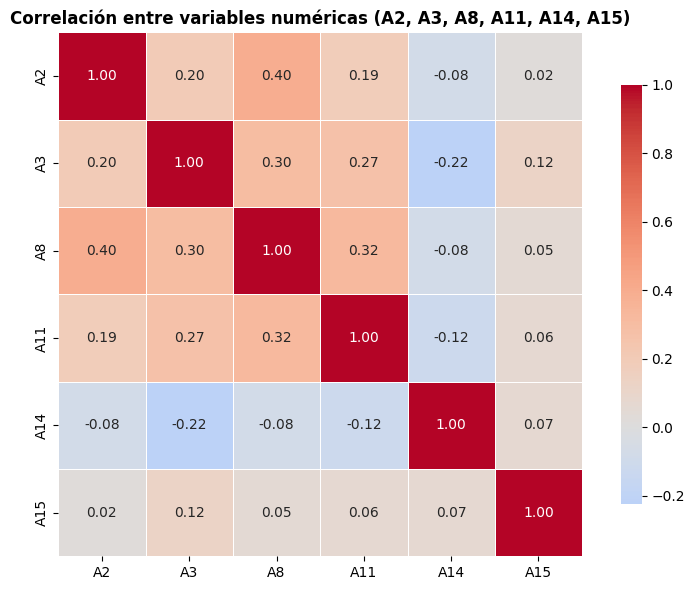

In [3]:
# Configurar pandas para mostrar toda la información sin truncar
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
print(df.head())
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())
print('\nDistribución de la clase objetivo A16:')
class_counts = df['A16'].value_counts(dropna=False)
class_percent = df['A16'].value_counts(normalize=True, dropna=False) * 100
print(class_counts)
print('\nPorcentaje por clase:')
print(class_percent.round(2))

if len(class_counts) == 2:
    ratio = class_counts.max() / class_counts.min()
    print('\nRelación mayoritaria/minoritaria:', round(ratio, 2))
    if ratio <= 1.5:
        print('Conclusión: sin desbalance fuerte.')
    else:
        print('Conclusión: hay desbalance — se aplicará upsampling en train.')

# Heatmap de correlación entre variables numéricas
numeric_preview = ['A2','A3','A8','A11','A14','A15']
num_data = df[numeric_preview].copy()
for col in num_data.columns:
    num_data[col] = pd.to_numeric(num_data[col], errors='coerce')
corr_matrix = num_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre variables numéricas (A2, A3, A8, A11, A14, A15)', fontweight='bold')
plt.tight_layout(); plt.show()


### Visualización de la distribución de clases

Representación gráfica del balance entre las clases del target.

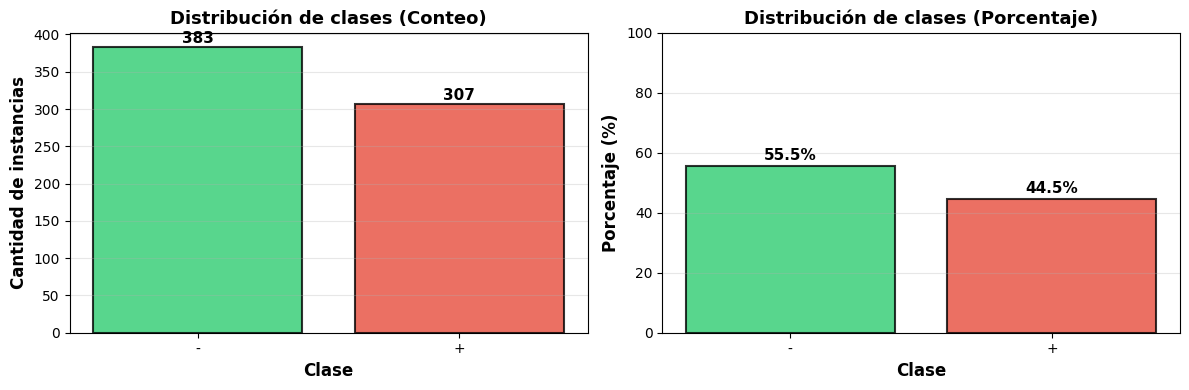

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Conteo absoluto
axes[0].bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de instancias', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de clases (Conteo)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

# Gráfico 2: Porcentaje
axes[1].bar(class_percent.index, class_percent.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de clases (Porcentaje)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_percent.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Preparación de tipos de datos e imputación

En este dataset hay variables numéricas y categóricas mezcladas. Se convierten explícitamente las numéricas, se imputan con **mediana** los faltantes numéricos y con **moda** los categóricos. Finalmente se mapea el target: `+`→1, `-`→0.

In [5]:
# Columnas numéricas y categóricas según la información oficial del dataset
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = [col for col in column_names if col not in numeric_cols + ['A16']]

# Conversión explícita de columnas numéricas
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputación: mediana para numéricas, moda para categóricas
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

# Codificación del target: + = aprobado (1), - = denegado (0)
df['A16'] = df['A16'].map({'+': 1, '-': 0})

df.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


## 4. Verificación del target mapeado

Si existieran valores distintos de `+` y `-` en `A16`, el `.map()` produciría `NaN` silenciosamente, contaminando el entrenamiento. Se verifica y se corrige si es necesario.

In [6]:
# Verificación crítica: mapeo no debe producir NaN en el target
n_nan_target = df['A16'].isna().sum()
if n_nan_target > 0:
    print(f'ADVERTENCIA: {n_nan_target} NaN en A16 tras el mapeo.')
    print('Valores únicos encontrados:', df['A16'].unique())
    df = df.dropna(subset=['A16'])
    print(f'Filas eliminadas con target inválido. Quedan: {len(df)}')
else:
    print('✓ Target A16 mapeado correctamente — sin valores NaN.')

print('Distribución final del target:')
print(df['A16'].value_counts())


✓ Target A16 mapeado correctamente — sin valores NaN.
Distribución final del target:
A16
0    383
1    307
Name: count, dtype: int64


## 5. Codificación de variables categóricas

Las columnas categóricas se convierten en variables numéricas con `get_dummies` y `drop_first=True` para evitar multicolinealidad perfecta. Se imprime el listado completo de columnas generadas para auditar el encoding.

In [7]:
X = pd.get_dummies(df.drop(columns=['A16']), columns=categorical_cols, drop_first=True)
y = df['A16'].values.astype(np.float32).reshape(-1, 1)

print('Shape de X (después de encoding):', X.shape)
print('Shape de y:', y.shape)
print(f'\nColumnas generadas ({len(X.columns)} total):')
print(X.columns.tolist())
X.head()


Shape de X (después de encoding): (690, 37)
Shape de y: (690, 1)

Columnas generadas (37 total):
['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_b', 'A4_u', 'A4_y', 'A5_gg', 'A5_p', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_t', 'A10_t', 'A12_t', 'A13_p', 'A13_s']


,A2,A3,A8,A11,A14,A15,A1_b,A4_u,A4_y,A5_gg,A5_p,A6_c,A6_cc,A6_d,A6_e,A6_ff,A6_i,A6_j,A6_k,A6_m,A6_q,A6_r,A6_w,A6_x,A7_dd,A7_ff,A7_h,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,30.83,0.000,1.25,1,202.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False
1,58.67,4.460,3.04,6,43.0,560,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False
2,24.50,0.500,1.50,0,280.0,824,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
3,27.83,1.540,3.75,5,100.0,3,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,True,False,False
4,20.17,5.625,1.71,0,120.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True


## 6. Conversión a arrays para modelado

Se convierte el DataFrame codificado a matrices NumPy (`float32`) para alimentar cualquier modelo de scikit-learn o red neuronal en PyTorch.

In [8]:
X = X.values.astype(np.float32)
y = y.astype(np.float32)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Shape de X: (690, 37)
Shape de y: (690, 1)


## 7. Split estratificado y balanceo (solo train)

Se divide manteniendo la proporción de clases con `stratify=y`. Se aplica **upsampling** de la clase minoritaria **exclusivamente en el train set**. El test permanece sin modificar para reflejar la distribución real del problema.

In [9]:
def upsample_minority(X, y, seed=42):
    rng = np.random.default_rng(seed)
    y_flat = y.reshape(-1).astype(int)

    idx0 = np.where(y_flat == 0)[0]
    idx1 = np.where(y_flat == 1)[0]

    if len(idx0) == len(idx1):
        return X, y

    if len(idx0) > len(idx1):
        idx_major, idx_minor = idx0, idx1
    else:
        idx_major, idx_minor = idx1, idx0

    idx_minor_upsampled = rng.choice(idx_minor, size=len(idx_major), replace=True)
    idx_balanced = np.concatenate([idx_major, idx_minor_upsampled])
    rng.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y.reshape(-1)
)

print('Proporción clase 1 en train (antes):', float(y_train_np.mean()))
print('Proporción clase 1 en test:', float(y_test_np.mean()))

X_train_np, y_train_np = upsample_minority(X_train_np, y_train_np, seed=42)

print('Proporción clase 1 en train (balanceado):', float(y_train_np.mean()))
print('Shapes:', X_train_np.shape, X_test_np.shape, y_train_np.shape, y_test_np.shape)

Proporción clase 1 en train (antes): 0.44565218687057495
Proporción clase 1 en test: 0.4420289993286133
Proporción clase 1 en train (balanceado): 0.5
Shapes: (612, 37) (138, 37) (612, 1) (138, 1)


## 8. Escalamiento

Normalización Z-score calculada **solo sobre train balanceado**. Se aplica al test con los mismos µ y σ del train — sin data leakage.

In [10]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_np, mu, sigma = featureNormalize(X_train_np)
X_test_np = (X_test_np - mu) / sigma

X_train_np.shape, X_test_np.shape


((612, 37), (138, 37))

## 9. Conversión a tensores

Los arreglos NumPy se convierten a tensores PyTorch (`float32`), formato requerido para definir y entrenar modelos con `torch.nn`.

In [11]:
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

print('Preparación terminada:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Preparación terminada:
X_train shape: torch.Size([612, 37])
y_train shape: torch.Size([612, 1])
X_test shape: torch.Size([138, 37])
y_test shape: torch.Size([138, 1])


## 10. Tabla resumen de variables

| Variable | Tipo original | Descripción (anonimizada) | Tratamiento aplicado |
|---|---|---|---|
| `A16` | Categórica binaria (target) | Decisión: `+`=aprobado, `-`=denegado | Mapeada a 1/0; verificada sin NaN |
| `A2`, `A3`, `A8`, `A11`, `A14`, `A15` | Numérica continua | Atributos financieros/personales | Conversión explícita + imputación mediana |
| `A1`,`A4`,`A5`,`A6`,`A7`,`A9`,`A10`,`A12`,`A13` | Categórica | Atributos cualitativos | Imputación moda + OHE `drop_first=True` |

**Decisiones clave:**
- Valores `?` leídos como `NaN` con `na_values='?'` directamente en la carga.
- Target verificado: ningún valor inesperado produce NaN silencioso tras el mapeo.
- Split estratificado conserva proporciones de clase en train y test.
- Upsampling **solo en train** (test refleja distribución real del problema).
- Normalización Z-score calculada sobre train balanceado, aplicada a test sin leakage.
